In [5]:
import os
import random
import numpy as np
import pandas as pd
from skimage import io, transform 
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from tqdm import tqdm
from sklearn.model_selection import GridSearchCV
from tensorflow.keras.callbacks import EarlyStopping
import time 
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras import layers, models

In [6]:
data = pd.read_csv("dataset.csv")


X_features = [] 
y_labels = []   
print(data.head())
print(data.shape)
nb_img_fracture = (data["fractured"]==1).sum()
print(nb_img_fracture)

         image_id  hand  leg  hip  shoulder  mixed  hardware  multiscan  \
0  IMG0000000.jpg     0    1    0         0      0         0          1   
1  IMG0000001.jpg     0    1    0         0      0         0          1   
2  IMG0000002.jpg     0    1    0         0      0         0          1   
3  IMG0000003.jpg     0    1    0         0      0         0          1   
4  IMG0000004.jpg     0    1    0         0      0         0          1   

   fractured  fracture_count  frontal  lateral  oblique  
0          0               0        1        1        0  
1          0               0        1        1        0  
2          0               0        1        1        0  
3          0               0        0        1        1  
4          0               0        0        1        1  
(4083, 13)
717


In [7]:
MAX_ROTATION_ANGLE = 15      
MAX_TRANSLATION_PIXELS = 10   

IMAGE_BASE_DIR = "images" 
IMG_SHAPE = (128, 128, 1) 

X_raw_images = []
y_labels = []

print("Début du chargement des images et de la Data Augmentation pour le CNN....")
total_rows = len(data)
loaded_count = 0
augmented_count = 0
error_count = 0

for index, row in data.iterrows():
    image_name = row['image_id']
    is_fractured = int(row['fractured']) 
    
    sub_folder = "Fractured" if is_fractured == 1 else "non_Fractured"
    image_path = os.path.join(IMAGE_BASE_DIR, sub_folder, image_name)
    
    if os.path.exists(image_path):
        try:
            img = io.imread(image_path, as_gray=True)
            img_resized = transform.resize(img, (128, 128), anti_aliasing=True)
            
            X_raw_images.append(img_resized)
            y_labels.append(is_fractured)
            loaded_count += 1
            
            if is_fractured == 1:
                
                img_aug = img_resized.copy()
                flip_type = random.choice(['none', 'horizontal', 'vertical'])
                if flip_type == 'horizontal':
                    img_aug = np.fliplr(img_aug)
                elif flip_type == 'vertical':
                    img_aug = np.flipud(img_aug)
                
                angle = random.uniform(-MAX_ROTATION_ANGLE, MAX_ROTATION_ANGLE)
  
                img_aug = transform.rotate(img_aug, angle, mode='edge')
                

                shift_x = random.uniform(-MAX_TRANSLATION_PIXELS, MAX_TRANSLATION_PIXELS)
                shift_y = random.uniform(-MAX_TRANSLATION_PIXELS, MAX_TRANSLATION_PIXELS)
                tform = transform.SimilarityTransform(translation=(shift_x, shift_y))
                img_aug = transform.warp(img_aug, tform, mode='edge')
                
                # On ajoute la nouvelle image augmentée au dataset
                X_raw_images.append(img_aug)
                y_labels.append(1)
                augmented_count += 1
                
        except Exception as e:
            error_count += 1
            pass  
    else:
        error_count += 1

    if index % 100 == 0 or index == total_rows - 1:
        print(f"Progression : {index + 1}/{total_rows} lignes traitées... ({loaded_count} d'origine + {augmented_count} augmentées)")

# Conversion en tableaux NumPy
X_raw_images = np.array(X_raw_images)
y_labels = np.array(y_labels)

# --- CALCUL DES STATISTIQUES FINALES ---
# On compte directement dans le tableau y_labels final
total_fractures = np.sum(y_labels == 1)
total_non_fractures = np.sum(y_labels == 0)

print(" BILAN DU CHARGEMENT & AUGMENTATION")
print("\n")
print(f"-> Images d'origine chargées avec succès : {loaded_count}")
print(f"-> Images de fractures créées par Augmentation : {augmented_count}")
print(f"-> Total d'images ignorées/corrompues          : {error_count}")
print("-"*50)
print(f"-> Nombre total d'images de FRACTURES (0rigine + Augm) : {total_fractures}")
print(f"-> Nombre total d'images de NON_FRACTURES              : {total_non_fractures}")
print("-"*50)
print(f"==> TOTAL GENERAL DES IMAGES PRÊTES POUR LE CNN        : {len(X_raw_images)}")
print("="*50 + "\n")

# Ajout de la dimension pour le canal noir et blanc (None, 128, 128, 1)
X_raw_images = np.expand_dims(X_raw_images, axis=-1)

Début du chargement des images et de la Data Augmentation pour le CNN....
Progression : 1/4083 lignes traitées... (1 d'origine + 0 augmentées)
Progression : 101/4083 lignes traitées... (101 d'origine + 8 augmentées)
Progression : 201/4083 lignes traitées... (201 d'origine + 17 augmentées)
Progression : 301/4083 lignes traitées... (301 d'origine + 21 augmentées)
Progression : 401/4083 lignes traitées... (401 d'origine + 25 augmentées)
Progression : 501/4083 lignes traitées... (501 d'origine + 38 augmentées)
Progression : 601/4083 lignes traitées... (601 d'origine + 40 augmentées)
Progression : 701/4083 lignes traitées... (701 d'origine + 43 augmentées)
Progression : 801/4083 lignes traitées... (801 d'origine + 53 augmentées)
Progression : 901/4083 lignes traitées... (901 d'origine + 58 augmentées)
Progression : 1001/4083 lignes traitées... (1001 d'origine + 60 augmentées)
Progression : 1101/4083 lignes traitées... (1101 d'origine + 64 augmentées)
Progression : 1201/4083 lignes traitées.

In [10]:
X_hog_features = []

print("Extraction des caractéristiques HOG sur le dataset augmenté...")

for i in tqdm(range(X_raw_images.shape[0]), desc="Extraction HOG"):
    img_2d = X_raw_images[i, :, :, 0] 
    
    features = hog(
        img_2d, 
        orientations=9, 
        pixels_per_cell=(16, 16), 
        cells_per_block=(2, 2), 
        visualize=False
    )
    X_hog_features.append(features)

X_hog_features = np.array(X_hog_features)

print(f"Extraction terminée ! Matrice HOG générée : {X_hog_features.shape}")

print("Séparation Split/Train")
X_train_hog, X_test_hog, y_train_hog, y_test_hog = train_test_split(
    X_hog_features, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)


print("\nConfiguration et lancement du Grid Search pour le SVM...")


param_grid = {'C': [0.1, 1, 10],'kernel': ['linear', 'rbf', 'poly'],'degree': [2, 3] }
svm_base = SVC(class_weight='balanced', random_state=42)


grid_search = GridSearchCV( estimator=svm_base, param_grid=param_grid, cv=3, 
                            scoring='accuracy', n_jobs=-1)

print("\nLancement du gridSerach pour l'optimisation du SVM....")
grid_search.fit(X_train_hog, y_train_hog)

svm_hog_augmented = grid_search.best_estimator_

print("\n RÉSULTATS DU GRID SEARCH")
print(f"Meilleurs hyperparamètres trouvés : {grid_search.best_params_}")
print(f"Meilleur score en validation croisée : {grid_search.best_score_ * 100:.2f}%")


y_pred_hog = svm_hog_augmented.predict(X_test_hog)

print("\n RÉSULTATS DU MODÈLE OPTIMISÉ HOG + SVM (SUR DATASET AUGMENTÉ) ")
print(classification_report(y_test_hog, y_pred_hog, target_names=['Sain', 'Fracture']))

Extraction des caractéristiques HOG sur le dataset augmenté...


Extraction HOG: 100%|██████████| 4741/4741 [00:13<00:00, 338.78it/s]


Extraction terminée ! Matrice HOG générée : (4741, 1764)
Séparation Split/Train

Configuration et lancement du Grid Search pour le SVM...

Lancement du gridSerach pour l'optimisation du SVM....

 RÉSULTATS DU GRID SEARCH
Meilleurs hyperparamètres trouvés : {'C': 10, 'degree': 2, 'kernel': 'rbf'}
Meilleur score en validation croisée : 85.05%

 RÉSULTATS DU MODÈLE OPTIMISÉ HOG + SVM (SUR DATASET AUGMENTÉ) 
              precision    recall  f1-score   support

        Sain       0.88      0.94      0.91       662
    Fracture       0.83      0.71      0.76       287

    accuracy                           0.87       949
   macro avg       0.85      0.82      0.84       949
weighted avg       0.86      0.87      0.86       949



In [12]:
print("Séparation des données en train/test...")
X_train, X_test, y_train, y_test = train_test_split(
    X_raw_images, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

print("Création des valeurs de test par époque...")
X_train_reel, X_val, y_train_reel, y_val_c = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)
model = models.Sequential([
 
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=IMG_SHAPE),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', 
              metrics=['accuracy', tf.keras.metrics.Recall(name='recall')])

model.summary() 

Séparation des données en train/test...
Création des valeurs de test par époque...


C:\Users\Godar\miniconda3\envs\torchnv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,304,193 (12.60 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
from tensorflow.keras.callbacks import EarlyStopping
import time 

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print(f"Poids appliqués pour équilibrer les classes : {class_weight_dict}")


early_stopping = EarlyStopping(monitor='accuracy', patience = 5, restore_best_weights=True)

start_time= time.time()

history = model.fit(X_train, y_train, epochs=15, batch_size=32, validation_data=(X_val, y_val_c),
                    class_weight=class_weight_dict, callbacks=[early_stopping])

end_time = time.time()
temps_app = end_time-start_time

Poids appliqués pour équilibrer les classes : {0: np.float64(0.7168241965973535), 1: np.float64(1.6530078465562337)}
Epoch 1/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 22s 160ms/step - accuracy: 0.6181 - loss: 0.6710 - recall: 0.4778 - val_accuracy: 0.7188 - val_loss: 0.6014 - val_recall: 0.5058
Epoch 2/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 19s 158ms/step - accuracy: 0.6640 - loss: 0.6109 - recall: 0.6539 - val_accuracy: 0.6432 - val_loss: 0.6060 - val_recall: 0.7733
Epoch 3/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 19s 156ms/step - accuracy: 0.7097 - loss: 0.5680 - recall: 0.6626 - val_accuracy: 0.7645 - val_loss: 0.5063 - val_recall: 0.7384
Epoch 4/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 19s 157ms/step - accuracy: 0.7447 - loss: 0.5345 - recall: 0.6983 - val_accuracy: 0.7680 - val_loss: 0.4847 - val_recall: 0.8488
Epoch 5/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 19s 158ms/step - accuracy: 0.7685 - loss: 0.4975 - recall: 0.7419 - val_accuracy: 0.7715 - val_loss: 0.4971 - val_recall: 0.9186
Epoch 6/15
119/119 ━━━━━━━━━━━━━━━━━━━

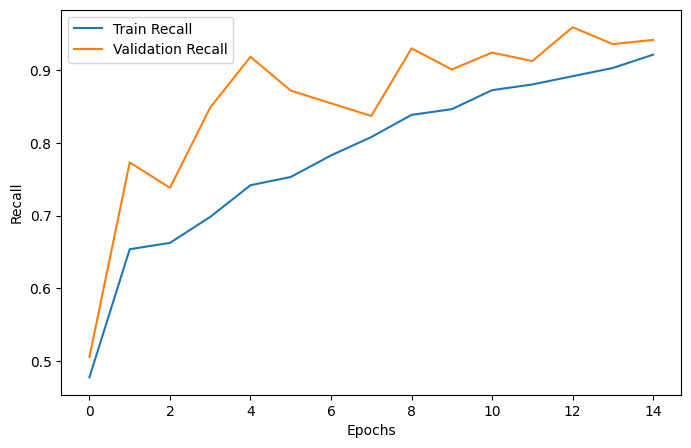

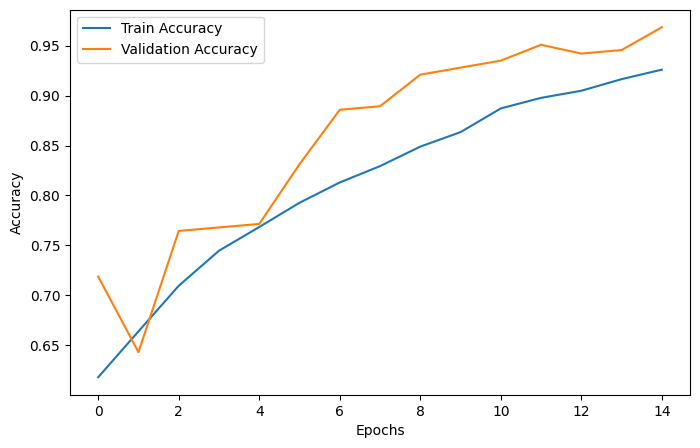

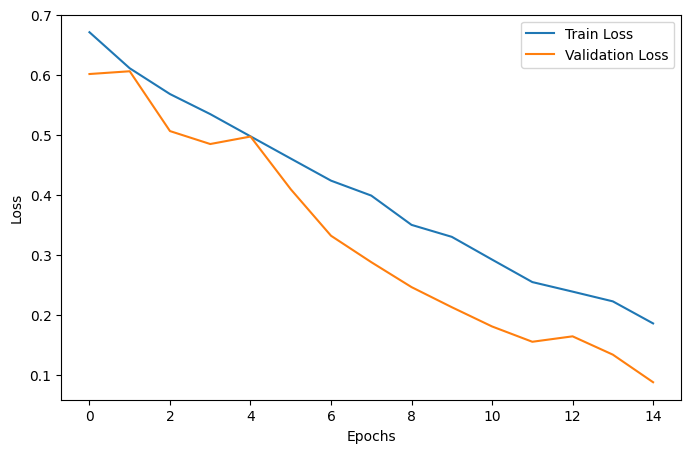

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
              precision    recall  f1-score   support

           0       0.86      0.87      0.86       662
           1       0.68      0.66      0.67       287

    accuracy                           0.80       949
   macro avg       0.77      0.76      0.77       949
weighted avg       0.80      0.80      0.80       949


 Training Time: 286.7 seconds,Test time: 1.6 seconds


In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.plot(history.history['recall'], label='Train Recall')
plt.plot(history.history['val_recall'], label='Validation Recall')

plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.legend()

plt.show()

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()
start_time = time.time()

y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred))
end_time = time.time()
temps_test = end_time - start_time
print(f"\n Training Time: {temps_app:.1f} seconds,Test time: {temps_test:.1f} seconds")

In [18]:
model.pop()
model.summary()
print("Extraction des features du CNN...")
features_train, features_test = model.predict(X_train), model.predict(X_test)
base_svm = SVC(class_weight='balanced', random_state=42)

param_grid = {'kernel': ['rbf', 'poly'],'degree': [2, 3, 4],  'C': [0.1, 1, 10]     
}

print("\nRecherche des meilleurs hyperparamètres pour le SVM hybride...")
grid_search = GridSearchCV(estimator=base_svm, param_grid=param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
grid_search.fit(features_train, y_train)

print("\n OPTIMISATION TERMINÉE ")
print(f"Meilleurs paramètres trouvés : {grid_search.best_params_}")

best_svm_hybrid = grid_search.best_estimator_

print("\nTest du modèle hybride optimisé....")

y_pred = best_svm_hybrid.predict(features_test)

print(classification_report(y_test, y_pred, target_names=['Sain', 'Fracture']))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9,912,452 (37.81 MB)

 Trainable params: 3,304,064 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,608,388 (25.21 MB)

Extraction des features du CNN...
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step

Recherche des meilleurs hyperparamètres pour le SVM hybride...

 OPTIMISATION TERMINÉE 
Meilleurs paramètres trouvés : {'C': 1, 'degree': 3, 'kernel': 'poly'}

Test du modèle hybride optimisé....
              precision    recall  f1-score   support

        Sain       0.86      0.86      0.86       662
    Fracture       0.68      0.68      0.68       287

    accuracy                           0.81       949
   macro avg       0.77      0.77      0.77       949
weighted avg       0.81      0.81      0.81       949

